# HAB V2 Full Portfolio Backtest

V2 changes:
- Risk blowout cap (SHRINK/CANCEL)
- Short side (allow_short)
- Structure fail relaxation (3 modes)
- Leverage cap (max_portfolio_leverage)
- PortfolioAnalyzer
- bandwidth = bb_width / ATR
- midpoint percentile tie handling

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == "note":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from strats.horizontal_accumulation_breakout_v1 import (
    HABConfig,
    HorizontalAccumulationBreakoutV1,
    PortfolioAnalyzer,
)

In [2]:
# ── Config ──────────────────────────────────────────────────

# Data path (try worktree first, fall back to main repo)
hab_bars_path = repo_root / "data" / "cache" / "normalized" / "hab_bars.csv"
if not hab_bars_path.exists():
    # worktree: data cache is in the main repo
    main_repo = Path("/Users/mm/Trading/stock-future")
    hab_bars_path = main_repo / "data" / "cache" / "normalized" / "hab_bars.csv"

data_quality_mode = "clamp"

config_overrides = dict(
    initial_capital=1_000_000,
    # Risk
    risk_per_trade=0.02,
    portfolio_risk_cap=0.12,
    group_risk_cap=0.06,
    risk_blowout_cap=1.5,
    risk_blowout_action="SHRINK",
    max_portfolio_leverage=3.0,
    # Box / entry
    box_lookback=7,
    box_width_atr_mult=1.5,
    tol_atr_mult=0.25,
    breakout_atr_mult=0.5,
    upper_shadow_ratio_max=0.25,
    initial_stop_atr_mult=0.4,
    # Exit
    structure_fail_bars=15,
    structure_fail_mode="CLOSE_BELOW_BOX",
    time_fail_bars=5,
    time_fail_target_r=0.5,
    trail_activate_r=1.0,
    trail_atr_mult=2.0,
    # Short side
    allow_short=True,
)

print("Config:")
for k, v in config_overrides.items():
    print(f"  {k}: {v}")

Config:
  initial_capital: 1000000
  risk_per_trade: 0.02
  portfolio_risk_cap: 0.12
  group_risk_cap: 0.06
  risk_blowout_cap: 1.5
  risk_blowout_action: SHRINK
  max_portfolio_leverage: 3.0
  box_lookback: 7
  box_width_atr_mult: 1.5
  tol_atr_mult: 0.25
  breakout_atr_mult: 0.5
  upper_shadow_ratio_max: 0.25
  initial_stop_atr_mult: 0.4
  structure_fail_bars: 15
  structure_fail_mode: CLOSE_BELOW_BOX
  time_fail_bars: 5
  time_fail_target_r: 0.5
  trail_activate_r: 1.0
  trail_atr_mult: 2.0
  allow_short: True


In [3]:
# ── Load & clean data ──────────────────────────────────────

bars = pd.read_csv(hab_bars_path, parse_dates=["date"])
bars = bars.sort_values(["date", "symbol"]).reset_index(drop=True)

ohlc_upper = bars[["open", "close"]].max(axis=1)
ohlc_lower = bars[["open", "close"]].min(axis=1)
invalid_mask = (bars["high"] < ohlc_upper) | (bars["low"] > ohlc_lower)

print(f"rows: {len(bars):,}")
print(f"symbols: {bars['symbol'].nunique()}")
print(f"date range: {bars['date'].min().date()} -> {bars['date'].max().date()}")
print(f"invalid OHLC rows: {invalid_mask.sum():,}")

backtest_bars = bars.copy()
if data_quality_mode == "clamp":
    backtest_bars.loc[invalid_mask, "high"] = backtest_bars.loc[
        invalid_mask, ["high", "open", "close"]
    ].max(axis=1)
    backtest_bars.loc[invalid_mask, "low"] = backtest_bars.loc[
        invalid_mask, ["low", "open", "close"]
    ].min(axis=1)

rows: 135,638
symbols: 91
date range: 2018-01-02 -> 2025-12-31
invalid OHLC rows: 144


In [4]:
# ── Run portfolio backtest ─────────────────────────────────

cfg = HABConfig(**config_overrides)
engine = HorizontalAccumulationBreakoutV1(cfg)
result = engine.run(backtest_bars)

trades = result.trades.copy()
portfolio_daily = result.portfolio_daily.copy()
open_positions = result.open_positions.copy()
cancelled_entries = result.cancelled_entries.copy()
daily_status = result.daily_status.copy()

portfolio_daily["date"] = pd.to_datetime(portfolio_daily["date"])

# Gap diagnostics
if hasattr(engine, "_gap_diagnostics") and engine._gap_diagnostics:
    print(f"\nData gap warnings ({len(engine._gap_diagnostics)}):")
    for g in engine._gap_diagnostics[:10]:
        print(f"  {g['symbol']} @ {g['date'].date()}: {g['gap_days']} days")

print(f"\nclosed trades: {len(trades)}")
print(f"open positions: {len(open_positions)}")
print(f"cancelled entries: {len(cancelled_entries)}")


Data gap warnings (224):
  A @ 2020-02-03: 11 days
  A @ 2023-10-09: 11 days
  A @ 2024-02-19: 11 days
  AG @ 2020-02-03: 11 days
  AG @ 2023-10-09: 11 days
  AG @ 2024-02-19: 11 days
  AL @ 2020-02-03: 11 days
  AL @ 2023-10-09: 11 days
  AL @ 2024-02-19: 11 days
  AO @ 2023-10-09: 11 days

closed trades: 113
open positions: 1
cancelled entries: 2


In [5]:
# ── PortfolioAnalyzer summary ──────────────────────────────

analyzer = PortfolioAnalyzer(result, cfg)
stats = analyzer.summary_stats()

print("Portfolio Summary")
print("=" * 40)
for k, v in stats.items():
    if isinstance(v, float):
        print(f"  {k:25s}: {v:>12.4f}")
    else:
        print(f"  {k:25s}: {v:>12}")

Portfolio Summary
  total_return             :      -0.0962
  cagr                     :      -0.0126
  sharpe                   :      -0.1528
  sortino                  :      -0.1055
  max_drawdown_pct         :      -0.2660
  total_days               :         2920
  total_trades             :          113
  win_rate                 :       0.3186
  profit_factor            :       0.8177
  avg_r_multiple           :      -0.0032
  expectancy               :    -962.3204


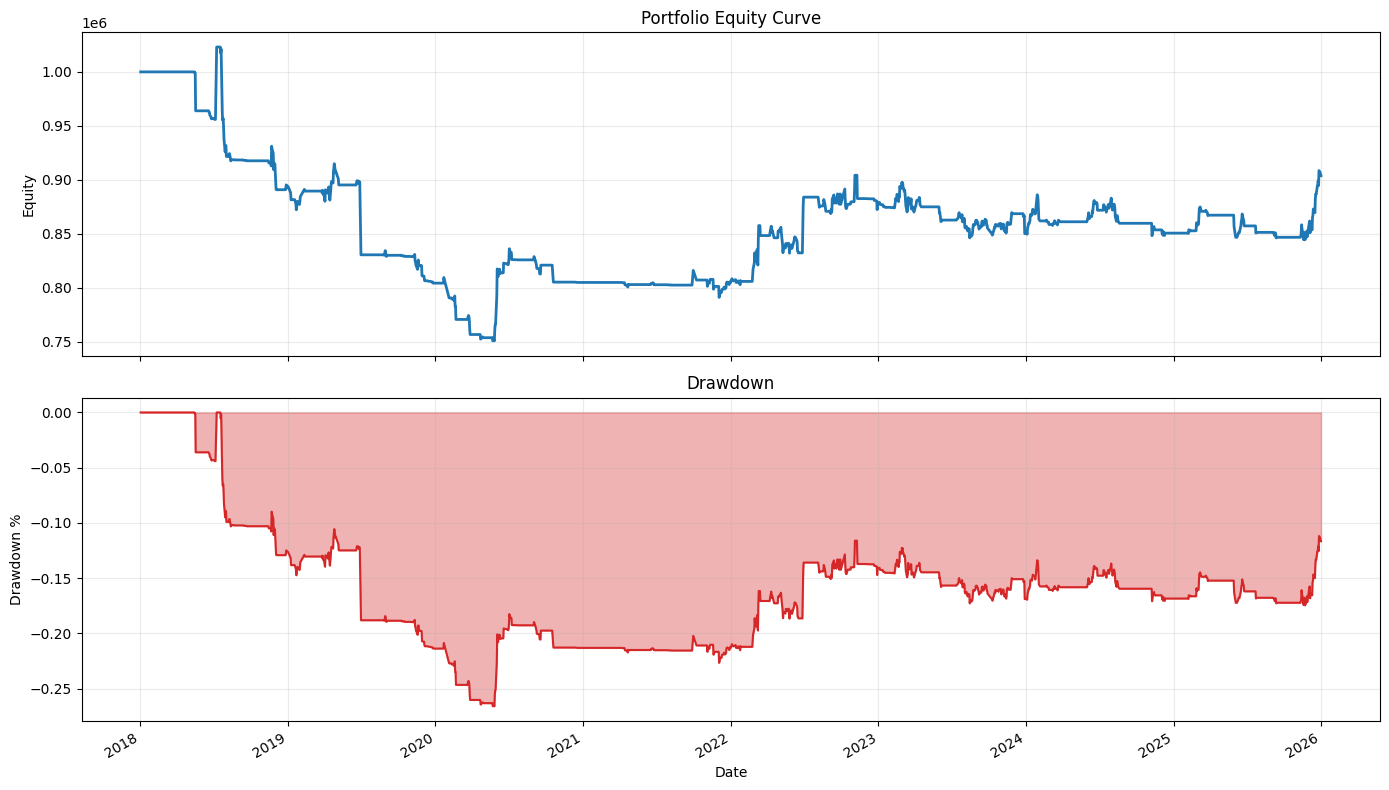

In [6]:
# ── Equity curve & drawdown ────────────────────────────────

ec = analyzer.equity_curve()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ec["date"], ec["equity"], linewidth=2)
axes[0].set_title("Portfolio Equity Curve")
axes[0].set_ylabel("Equity")
axes[0].grid(True, alpha=0.25)

axes[1].fill_between(ec["date"], ec["drawdown_pct"], 0, alpha=0.35, color="tab:red")
axes[1].plot(ec["date"], ec["drawdown_pct"], color="tab:red", linewidth=1.5)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown %")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [7]:
# ── Drawdown episodes ──────────────────────────────────────

dd_eps = analyzer.drawdown_episodes()
if dd_eps.empty:
    print("No drawdown episodes.")
else:
    print(f"Top 10 drawdown episodes (of {len(dd_eps)}):")
    display(dd_eps.sort_values("max_drawdown_pct").head(10))

Top 10 drawdown episodes (of 2):


,start_date,trough_date,recovery_date,max_drawdown_pct,duration_days
1,2018-07-19,2020-05-26,NaT,-0.265971,2722
0,2018-05-16,2018-07-04,2018-07-09,-0.044025,54


,group_name,net_pnl_sum,trade_count,win_count,loss_count,avg_r_multiple,win_rate
0,agri,23241.748881,2,2,0,0.758310,1.00
3,chem,-3532.000000,2,1,1,-0.097930,0.50
6,precious,-5600.000000,1,0,1,-0.758225,0.00
1,base_metal,-6012.000000,1,0,1,-0.459125,0.00
2,black,-11329.469102,5,2,3,-0.119050,0.40
5,index,-40120.000000,2,0,2,-1.372536,0.00
4,commodity,-65390.489159,100,31,69,0.028758,0.31


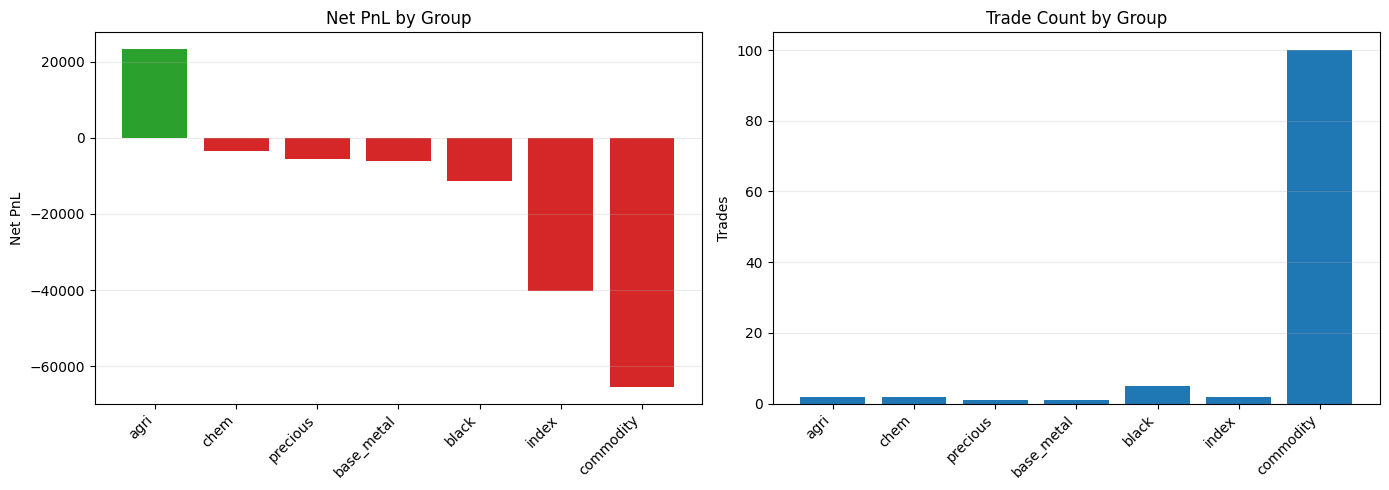

In [8]:
# ── Group contribution ─────────────────────────────────────

gc = analyzer.group_contribution()
if gc.empty:
    print("No trades for group analysis.")
else:
    display(gc.sort_values("net_pnl_sum", ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    gc_sorted = gc.sort_values("net_pnl_sum", ascending=False)
    colors = ["tab:green" if x > 0 else "tab:red" for x in gc_sorted["net_pnl_sum"]]
    axes[0].bar(gc_sorted["group_name"], gc_sorted["net_pnl_sum"], color=colors)
    axes[0].set_title("Net PnL by Group")
    axes[0].set_ylabel("Net PnL")
    axes[0].grid(True, axis="y", alpha=0.25)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right")

    axes[1].bar(gc_sorted["group_name"], gc_sorted["trade_count"], color="tab:blue")
    axes[1].set_title("Trade Count by Group")
    axes[1].set_ylabel("Trades")
    axes[1].grid(True, axis="y", alpha=0.25)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

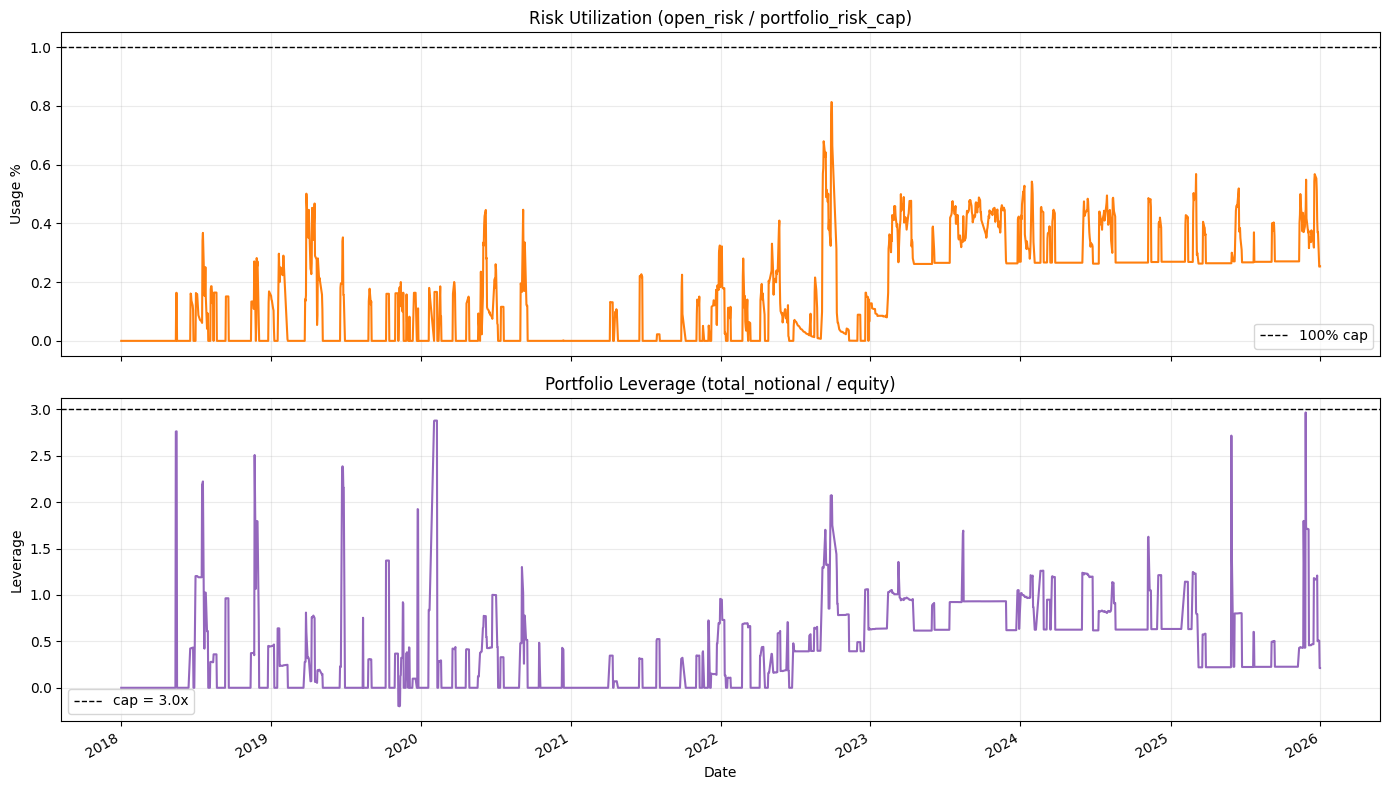

In [9]:
# ── Risk utilization & leverage ────────────────────────────

ru = analyzer.risk_utilization()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ru["date"], ru["risk_usage_pct"], linewidth=1.5, color="tab:orange")
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1, label="100% cap")
axes[0].set_title("Risk Utilization (open_risk / portfolio_risk_cap)")
axes[0].set_ylabel("Usage %")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(ru["date"], ru["leverage"], linewidth=1.5, color="tab:purple")
axes[1].axhline(
    cfg.max_portfolio_leverage, color="black", linestyle="--", linewidth=1,
    label=f"cap = {cfg.max_portfolio_leverage}x",
)
axes[1].set_title("Portfolio Leverage (total_notional / equity)")
axes[1].set_ylabel("Leverage")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

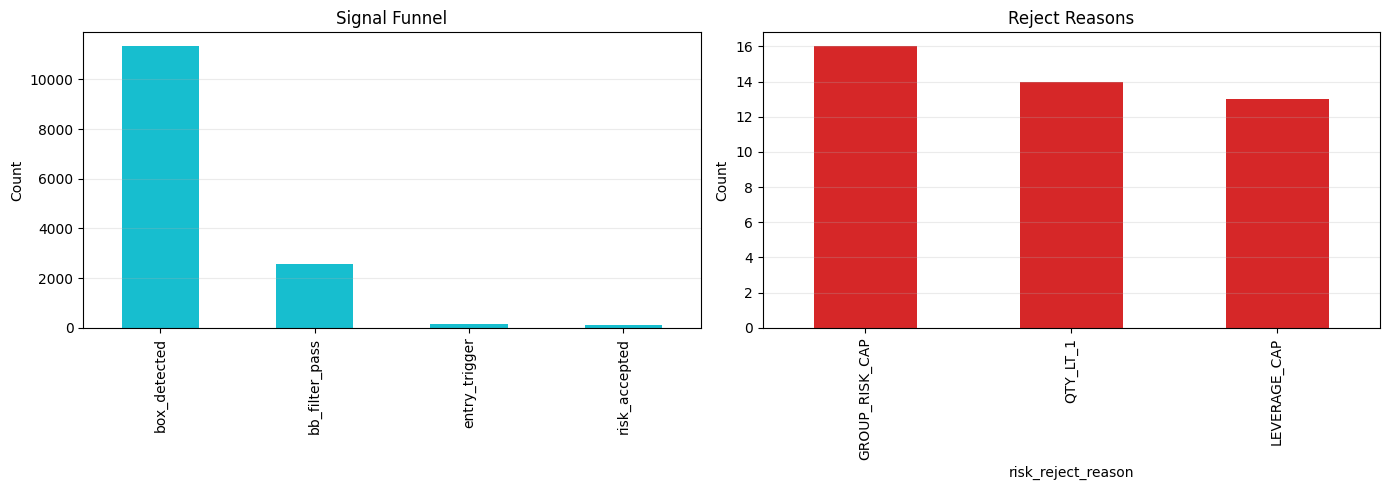

In [10]:
# ── Signal funnel ──────────────────────────────────────────

sd = analyzer.signal_density()

funnel = {
    "box_detected": int(daily_status["is_box"].fillna(False).sum()),
    "bb_filter_pass": int(
        (daily_status["is_box"].fillna(False) & daily_status["bb_filter_pass"].fillna(False)).sum()
    ),
    "entry_trigger": int(daily_status["entry_trigger_pass"].fillna(False).sum()),
    "risk_accepted": int(
        (daily_status["entry_trigger_pass"].fillna(False) & daily_status["risk_reject_reason"].isna()).sum()
    ),
}

reject_counts = (
    daily_status["risk_reject_reason"].dropna().value_counts().sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(funnel).plot(kind="bar", ax=axes[0], color="tab:cyan")
axes[0].set_title("Signal Funnel")
axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", alpha=0.25)

if reject_counts.empty:
    axes[1].text(0.5, 0.5, "No rejects", ha="center", va="center")
else:
    reject_counts.plot(kind="bar", ax=axes[1], color="tab:red")
    axes[1].set_title("Reject Reasons")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

Long vs Short breakdown:


,count,net_pnl_sum,win_rate,avg_r
side,,,,
LONG,56,85739.576816,0.446429,0.200177
SHORT,57,-194481.786196,0.192982,-0.202999


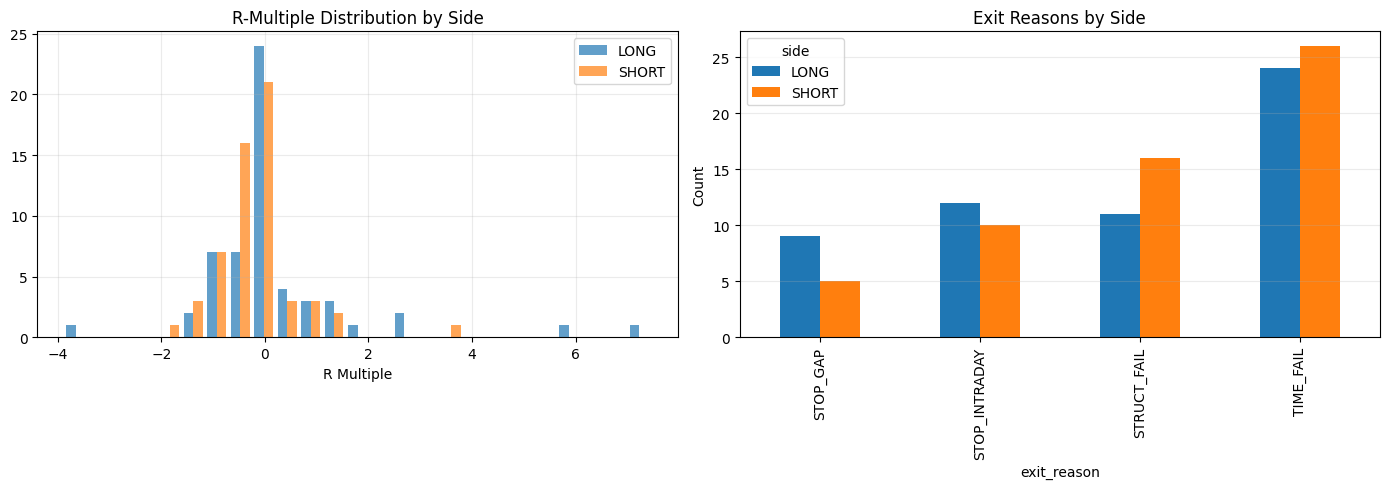

In [11]:
# ── Trade direction breakdown ──────────────────────────────

if trades.empty:
    print("No trades.")
else:
    trades["side"] = trades["direction"].map({1: "LONG", -1: "SHORT"})

    side_stats = trades.groupby("side").agg(
        count=("net_pnl", "count"),
        net_pnl_sum=("net_pnl", "sum"),
        win_rate=("net_pnl", lambda x: (x > 0).mean()),
        avg_r=("r_multiple", "mean"),
    )
    print("Long vs Short breakdown:")
    display(side_stats)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        [trades.loc[trades["direction"] == 1, "r_multiple"],
         trades.loc[trades["direction"] == -1, "r_multiple"]],
        bins=25, alpha=0.7, label=["LONG", "SHORT"], color=["tab:blue", "tab:orange"],
    )
    axes[0].set_title("R-Multiple Distribution by Side")
    axes[0].set_xlabel("R Multiple")
    axes[0].legend()
    axes[0].grid(True, alpha=0.25)

    exit_by_side = trades.groupby(["side", "exit_reason"]).size().unstack(fill_value=0)
    exit_by_side.T.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Exit Reasons by Side")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

Trades shrunk by blowout cap: 4


,symbol,direction,entry_date,qty,original_qty,risk_blowout_ratio,qty_shrink_reason
17,BB,1,2019-03-29,2,4.0,1.281903,RISK_BLOWOUT
46,BB,-1,2020-09-07,1,2.0,1.188292,RISK_BLOWOUT
106,T,-1,2025-05-30,1,2.0,1.204741,RISK_BLOWOUT
110,T,-1,2025-11-27,1,2.0,1.257173,RISK_BLOWOUT



Cancelled by blowout:
  count: 1


,symbol,entry_date,risk_blowout_ratio,cancel_reason
1,TL,2025-11-24,1.828748,RISK_BLOWOUT_SHRINK_TO_ZERO


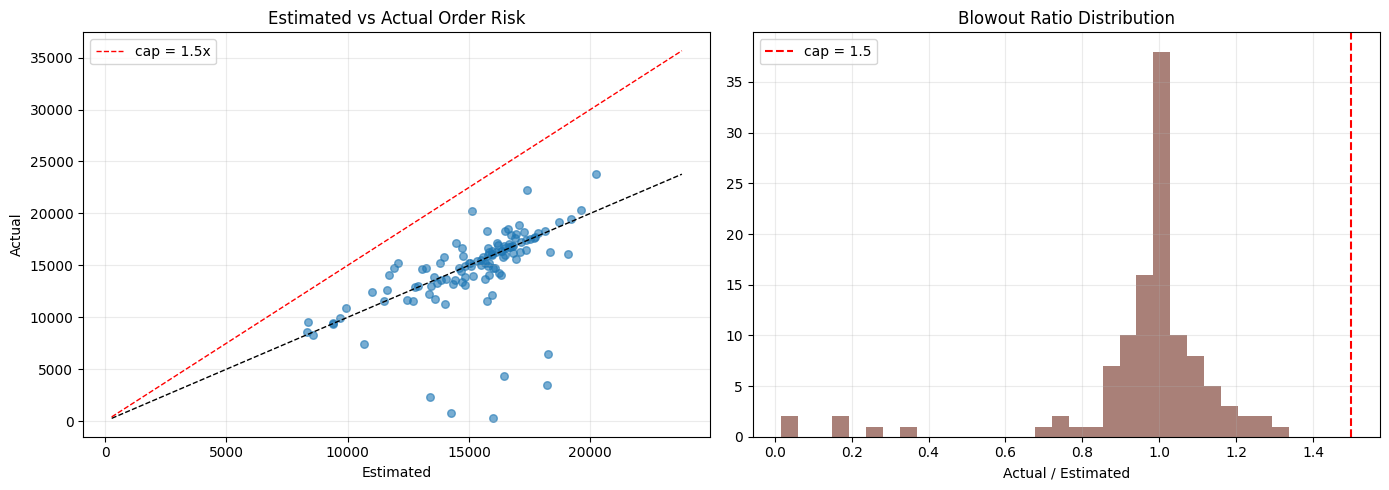

In [12]:
# ── Risk blowout audit ─────────────────────────────────────

if trades.empty:
    print("No trades.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = trades["estimated_order_risk"].astype(float)
    y = trades["actual_order_risk"].astype(float)
    lo, hi = float(min(x.min(), y.min())), float(max(x.max(), y.max()))

    axes[0].scatter(x, y, alpha=0.6, s=30)
    axes[0].plot([lo, hi], [lo, hi], "--k", linewidth=1)
    axes[0].plot([lo, hi], [lo * cfg.risk_blowout_cap, hi * cfg.risk_blowout_cap],
                "--r", linewidth=1, label=f"cap = {cfg.risk_blowout_cap}x")
    axes[0].set_title("Estimated vs Actual Order Risk")
    axes[0].set_xlabel("Estimated")
    axes[0].set_ylabel("Actual")
    axes[0].legend()
    axes[0].grid(True, alpha=0.25)

    axes[1].hist(trades["risk_blowout_ratio"].astype(float), bins=30, alpha=0.75, color="tab:brown")
    axes[1].axvline(cfg.risk_blowout_cap, color="red", linestyle="--", label=f"cap = {cfg.risk_blowout_cap}")
    axes[1].set_title("Blowout Ratio Distribution")
    axes[1].set_xlabel("Actual / Estimated")
    axes[1].legend()
    axes[1].grid(True, alpha=0.25)

    shrunk = trades[trades["qty_shrink_reason"].notna()]
    print(f"Trades shrunk by blowout cap: {len(shrunk)}")
    if not shrunk.empty:
        display(shrunk[["symbol", "direction", "entry_date", "qty", "original_qty",
                        "risk_blowout_ratio", "qty_shrink_reason"]])

    print(f"\nCancelled by blowout:")
    if not cancelled_entries.empty:
        blowout_cancel = cancelled_entries[
            cancelled_entries["cancel_reason"].str.contains("RISK_BLOWOUT", na=False)
        ]
        print(f"  count: {len(blowout_cancel)}")
        if not blowout_cancel.empty:
            display(blowout_cancel[["symbol", "entry_date", "risk_blowout_ratio", "cancel_reason"]])
    else:
        print("  0")

    plt.tight_layout()
    plt.show()

Symbols with trades: 51


,symbol,trade_count,net_pnl_sum,win_rate,avg_r,long_count,short_count
0,AG,4,100785.535099,50.000000,1.979679,3,1
1,RI,7,24085.267062,28.571429,0.156354,5,2
2,M,2,23241.748881,100.000000,0.758310,1,1
3,BU,1,19177.700366,100.000000,1.302268,1,0
4,EB,1,18209.061144,100.000000,1.072988,0,1
5,BB,8,15677.855161,12.500000,0.261762,3,5
6,B,3,14870.033910,66.666667,0.326803,1,2
7,CJ,5,14733.573809,60.000000,0.332817,1,4
8,HC,2,14160.000000,50.000000,0.413471,1,1
9,WH,2,10000.000000,50.000000,1.234339,2,0


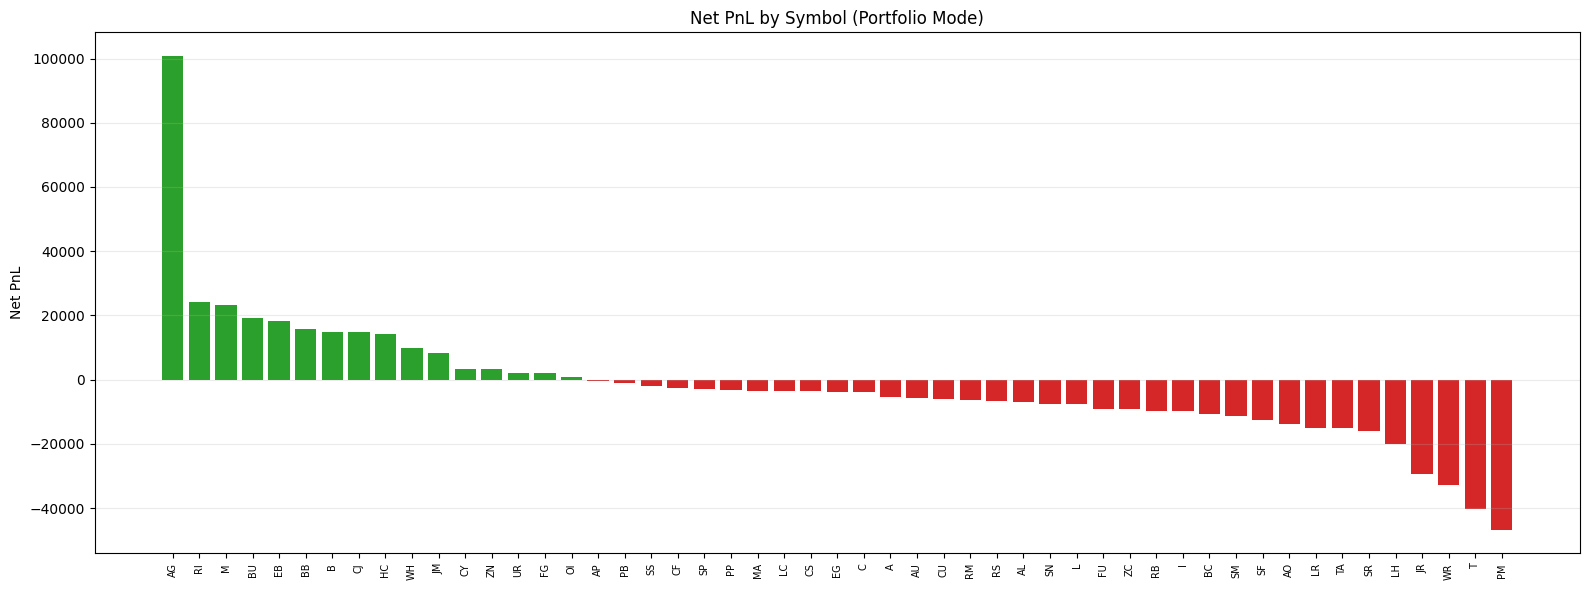

In [13]:
# ── Per-symbol ranking ─────────────────────────────────────

if trades.empty:
    print("No trades for symbol ranking.")
else:
    sym_stats = trades.groupby("symbol").agg(
        trade_count=("net_pnl", "count"),
        net_pnl_sum=("net_pnl", "sum"),
        win_rate=("net_pnl", lambda x: (x > 0).mean() * 100),
        avg_r=("r_multiple", "mean"),
        long_count=("direction", lambda x: (x == 1).sum()),
        short_count=("direction", lambda x: (x == -1).sum()),
    ).sort_values("net_pnl_sum", ascending=False).reset_index()

    print(f"Symbols with trades: {len(sym_stats)}")
    display(sym_stats.head(20))

    fig, ax = plt.subplots(figsize=(16, 6))
    colors = ["tab:green" if x > 0 else "tab:red" for x in sym_stats["net_pnl_sum"]]
    ax.bar(sym_stats["symbol"], sym_stats["net_pnl_sum"], color=colors)
    ax.set_title("Net PnL by Symbol (Portfolio Mode)")
    ax.set_ylabel("Net PnL")
    ax.grid(True, axis="y", alpha=0.25)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=90, fontsize=7)
    plt.tight_layout()
    plt.show()

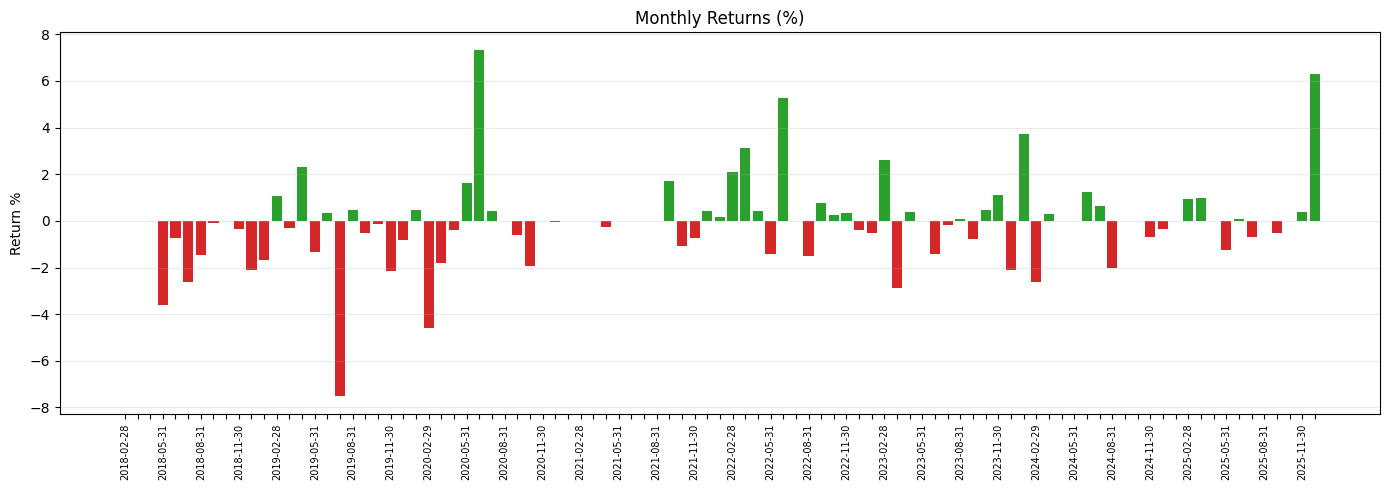


Annual Returns:


,year,return_pct
0,2019,-10.159416
1,2020,0.078992
2,2021,-0.029060
3,2022,9.230525
4,2023,-3.282634
5,2024,0.056398
6,2025,6.240103


In [14]:
# ── Monthly returns ────────────────────────────────────────

monthly = analyzer.periodic_returns(freq="M")
if monthly.empty:
    print("Not enough data for monthly returns.")
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["tab:green" if x > 0 else "tab:red" for x in monthly["return_pct"]]
    ax.bar(monthly["period"].astype(str), monthly["return_pct"] * 100, color=colors, width=0.8)
    ax.set_title("Monthly Returns (%)")
    ax.set_ylabel("Return %")
    ax.grid(True, axis="y", alpha=0.25)
    # Show every 3rd label
    for i, label in enumerate(ax.xaxis.get_ticklabels()):
        if i % 3 != 0:
            label.set_visible(False)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=90, fontsize=7)
    plt.tight_layout()
    plt.show()

    # Annual summary
    annual = analyzer.periodic_returns(freq="Y")
    if not annual.empty:
        annual["year"] = annual["period"].dt.year
        annual["return_pct"] = annual["return_pct"] * 100
        print("\nAnnual Returns:")
        display(annual[["year", "return_pct"]])

In [15]:
# ── Trades table (full) ────────────────────────────────────

if not trades.empty:
    display_cols = [
        "symbol", "direction", "entry_date", "exit_date", "exit_reason",
        "entry_fill", "exit_fill", "qty", "original_qty", "qty_shrink_reason",
        "r_multiple", "net_pnl", "risk_blowout_ratio",
    ]
    cols = [c for c in display_cols if c in trades.columns]
    display(trades[cols].sort_values("exit_date"))

,symbol,direction,entry_date,exit_date,exit_reason,entry_fill,exit_fill,qty,original_qty,qty_shrink_reason,r_multiple,net_pnl,risk_blowout_ratio
0,JR,-1,2018-05-16,2018-05-18,STOP_GAP,3941.000,3992.000000,35,NaN,None,-1.776151,-36050.000000,1.035720
1,TA,-1,2018-06-20,2018-06-27,TIME_FAIL,4289.000,4361.000000,19,NaN,None,-0.360945,-7030.000000,1.014850
2,JR,-1,2018-07-19,2018-07-23,STOP_GAP,3858.000,3966.000000,8,NaN,None,-1.067989,-17360.000000,0.886555
3,PM,1,2018-07-03,2018-07-23,STOP_GAP,2559.000,2608.000000,9,NaN,None,1.146311,21960.000000,1.024055
4,RI,1,2018-07-19,2018-07-30,STOP_INTRADAY,2557.000,2407.407919,8,NaN,None,-1.010095,-24014.732938,1.173787
...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,MA,1,2025-07-23,2025-07-24,STRUCT_FAIL,2319.000,2277.000000,14,NaN,None,-0.355086,-5964.000000,1.008405
109,CJ,-1,2025-09-05,2025-09-12,STRUCT_FAIL,11504.000,11731.000000,4,NaN,None,-0.327372,-4580.000000,0.922216
110,T,-1,2025-11-27,2025-12-04,TIME_FAIL,106.985,108.945000,1,2.0,RISK_BLOWOUT,-1.290793,-19610.000000,1.257173
111,SR,-1,2025-12-17,2025-12-25,STRUCT_FAIL,5173.000,5304.000000,12,NaN,None,-0.974888,-15840.000000,0.950843
